Guided Practice: Implementing K-Means Algorithm From Scratch

Welcome to the practice notebook. In this assignment, you will implement the K-Means algorithm from scratch using only basic libraries. After implementing the algorithm, we will generate a dataset with spherical clusters and evaluate the performance of your implementation.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import torch

# Device configuration for future deep learning integrations
device = ('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Configured device: {device}")

Configured device: cpu


Step 1: Generating Synthetic Data

We will generate a 2D dataset containing 4 clear spherical clusters so we can visually inspect the results.

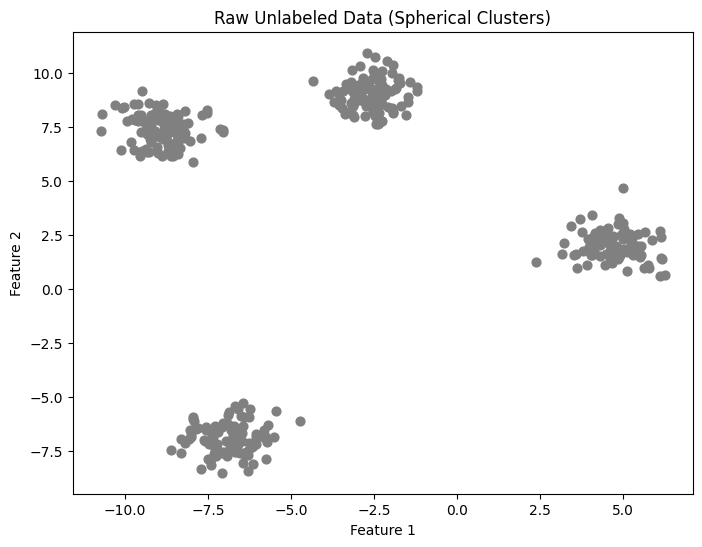

In [9]:
# Generate spherical clusters
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.70, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray')
plt.title("Raw Unlabeled Data (Spherical Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Step 2: Initialize Centroids

Complete the function below. It must randomly select k points from the dataset X to serve as the initial cluster centers.

In [10]:
def initialize_centroids(X, k):
    """
    Randomly select k data points from X as the initial centroids.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    k : int, number of clusters
    
    Returns:
    centroids : array of shape (k, n_features)
    """
    # TODO: Implement centroid initialization
    n_samples = X.shape[0]
    
    # Randomly choose k unique indices
    random_indices = np.random.choice(n_samples, k, replace=False)
    
    # Select corresponding data points as centroids
    centroids = X[random_indices]
    return centroids

Step 3: Cluster Assignment Step

For each data point, calculate the Euclidean distance between it and each of the k centroids, and assign the point to its closest centroid.

In [11]:
def assign_clusters(X, centroids):
    """
    Assign each data point to the closest centroid.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    centroids : array of shape (k, n_features)
    
    Returns:
    labels : array of shape (n_samples,) containing the index of the closest centroid for each point
    """
    # TODO: Implement cluster assignment
    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )
    
    labels = np.argmin(distances, axis=1)
    
    return labels

Step 4: Update Centroids Step

After all points have been assigned to clusters, recalculate the position of each centroid. The new position will be the mathematical mean of all points assigned to that specific cluster.

In [12]:
def update_centroids(X, labels, k):
    """
    Calculate new centroids as the mean of the points assigned to each cluster.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    labels : array of shape (n_samples,)
    k : int, number of clusters
    
    Returns:
    new_centroids : array of shape (k, n_features)
    """
    # TODO: Implement centroid updating
    n_features = X.shape[1]
    new_centroids = np.zeros((k, n_features))

    for j in range(k):
        points_in_cluster = X[labels == j]
        new_centroids[j] = points_in_cluster.mean(axis=0)

    return new_centroids

Step 5: Assemble the Complete Algorithm

Now, combine the three previous steps into a single function that runs the K-Means loop until convergence. Convergence occurs when the position of the centroids stops changing between iterations.

In [13]:
def kmeans(X, k, max_iters=100):
    """
    Full K-Means algorithm implementation.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    k : int, number of clusters
    max_iters : int, maximum number of iterations to prevent infinite loops
    
    Returns:
    centroids : final centroid positions
    labels : final cluster assignments
    """
    # 1. Initialize centroids
    centroids = initialize_centroids(X, k)
    
    for iteration in range(max_iters):
        # 2. Assign clusters
        labels = assign_clusters(X, centroids)
        
        # 3. Store old centroids to check for convergence
        old_centroids = centroids.copy()
        
        # 4. Update centroids
        centroids = update_centroids(X, labels, k)
        
        # 5. Check convergence (if centroids did not change, break the loop)
        # TODO: Implement convergence check
        if np.allclose(old_centroids, centroids):
            print(f"Converged at iteration {iteration}")
            break
        
    return centroids, labels

Step 6: Execution and Visualization

Uncomment the code below to run your implementation and visualize the results on the graph. The final centroids will be marked with a red X.

Converged at iteration 6


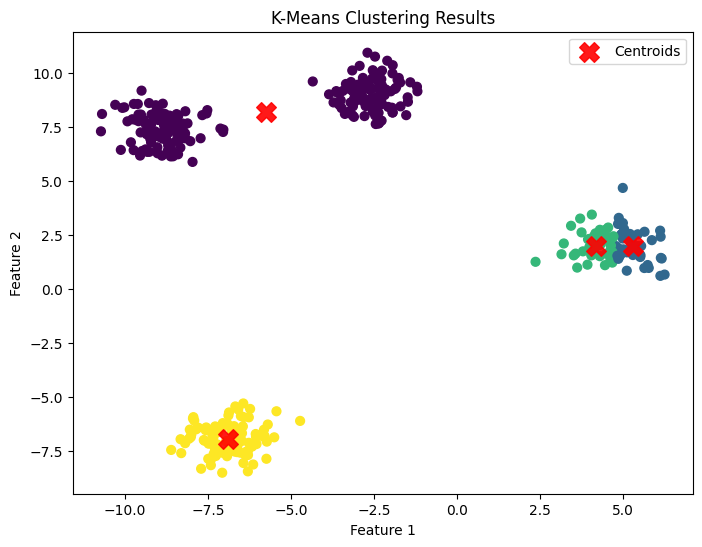

In [14]:
# Set number of clusters
k = 4

# Run the implemented algorithm
final_centroids, final_labels = kmeans(X, k)

# Plotting the final results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, s=40, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Centroids')
plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()